In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

In [2]:
# CHANG THIS !!!!!
ckpt_path = "logs/tom_pos-DM_scaled_n9/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=257-total_loss=0.76506275.ckpt"

# load data

In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

# CHANG THIS !!!!!
ckpt_path = "logs/tom_pos-DM_scaled_n9/pde_params_tsense/lightning_logs/version_1/checkpoints/epoch=174-total_loss=0.88114280.ckpt"

model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]

n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])
n_dimension =10

# the DS
DS_t7 = reader.TwoTimpepoint_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                            n_dimension = n_dimension,
                              cellstate_key=cellstate_key,  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False,
                              batchsize = 300
                              )
# adata
t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b.cpu().numpy().reshape(n_timepoint, -1)
cellstate = torch.from_numpy(DS_t7.cellstate).float().requires_grad_()


## forward prediction

In [4]:

if "u" in dir(pde_model):
    u_pred_ls = []
    chunk_size= 500

    s_ts = DS_t7.s.float().to(device)
    t_ts = DS_t7.t_b.float().to(device)

    with torch.no_grad():
        for i in tqdm(range(0, len(t_ts), chunk_size)):
            u_pred = pde_model(s_ts[i:i+chunk_size],  t_ts[i:i+chunk_size])
            u_pred_ls.append(u_pred.detach().cpu().numpy())
    u_pred_b = np.concatenate(u_pred_ls, axis=0).reshape(n_timepoint,-1)

  0%|          | 0/890 [00:00<?, ?it/s]

prediction of shape (9, 49390)
prediction of shape (9, 49390)


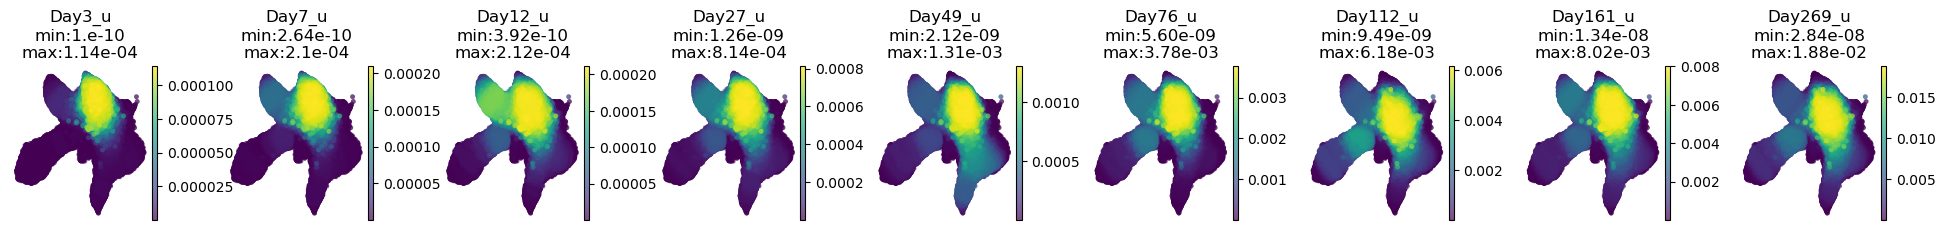

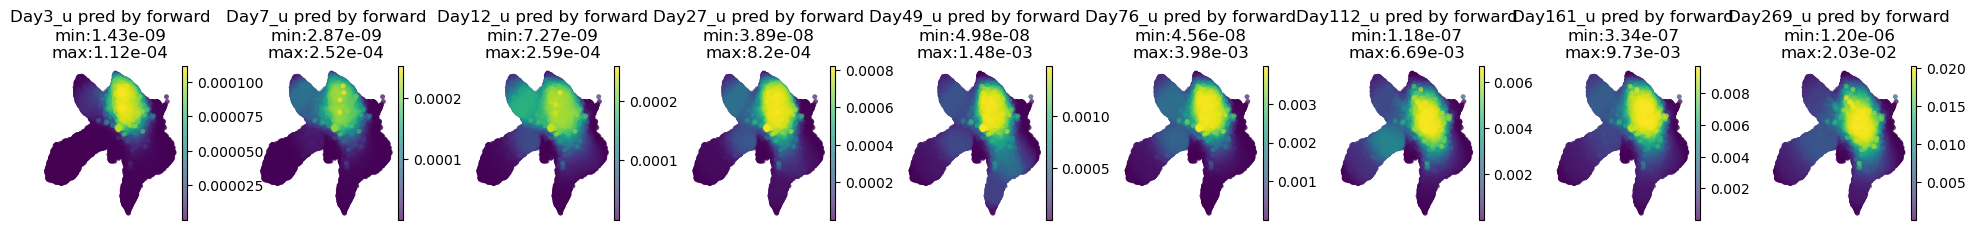

In [5]:
PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);
PINN.pl.params_in_umap(t7_ad, u_pred_b, param='u pred by forward', cell_of_t=False);

## integral

In [6]:
## predict u with ode integrat
u_int_all = []
chunk_size= 500
# t_list = timepoints / 15
it = 0
for t0, t1 in tqdm(zip(timepoints[:-1], timepoints[1:])):

    u_t_ls = []

    for i in range(0, len(cellstate), chunk_size):

        s0 = cellstate[i:i+chunk_size].to(device)
        tompos_u0 = torch.from_numpy(u_b[it, i:i+chunk_size]).float().to(device).requires_grad_()
        init_condition = (tompos_u0, s0)

        step_size = np.around((t1 - t0)/15, decimals=1).item() 
        step_size = step_size if step_size > 0 else 0.05
        step_size = min(step_size, 0.4)


        u_t, s_t = odeint(
                        pde_model.ode_func,
                        init_condition,
                        torch.tensor([t0, t1]).type(torch.float32).to(device),
                        atol=1e-8,
                        rtol=1e-8,
                        method='midpoint',
                        options = {'step_size': step_size}
                    )

        torch.cuda.empty_cache()

        u_t_ls.append(u_t.detach().cpu().numpy())
        del u_t, s_t
        torch.cuda.empty_cache()

    u_int = np.concatenate(u_t_ls, axis=1)
    
    u_int_all.append(u_int)
    it+=0

PINN.pl.params_in_umap(t7_ad, u_int[:-2], param='u by integrat', cell_of_t=False);
PINN.pl.params_in_umap(t7_ad, u_int, timepoints=timepoints, param='u by integrat', cell_of_t=False);

0it [00:00, ?it/s]

prediction of shape (7, 25948)
prediction of shape (7, 25948)


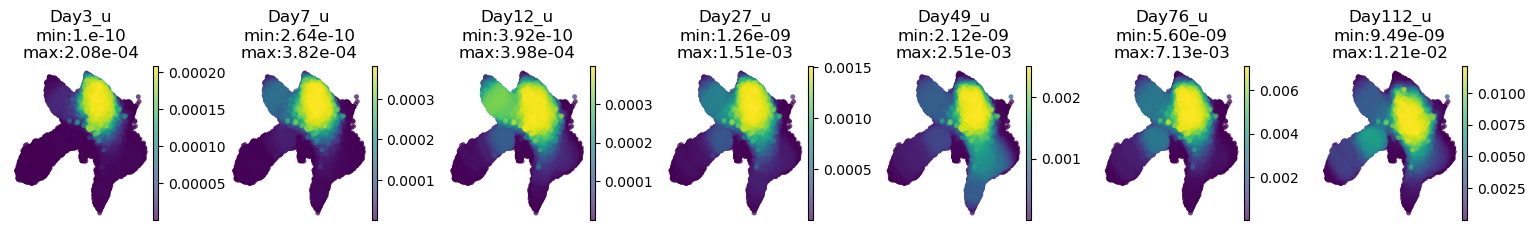

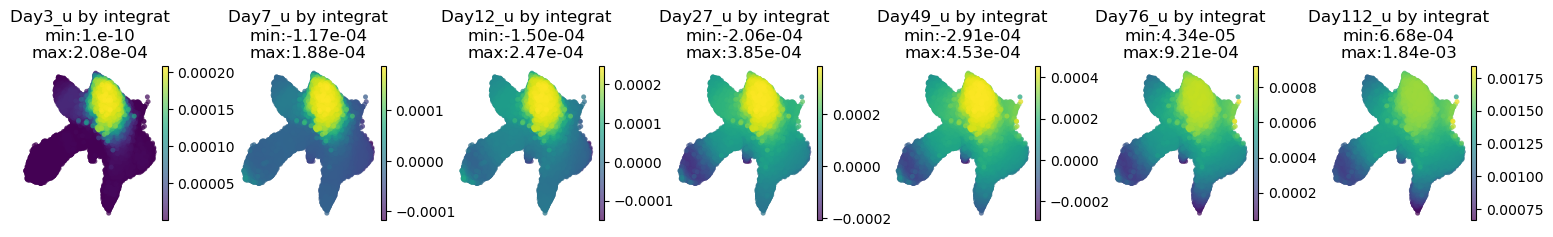

In [16]:
PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);
PINN.pl.params_in_umap(t7_ad, u_int[:-2], param='u by integrat', cell_of_t=False);

prediction of shape (9, 25948)


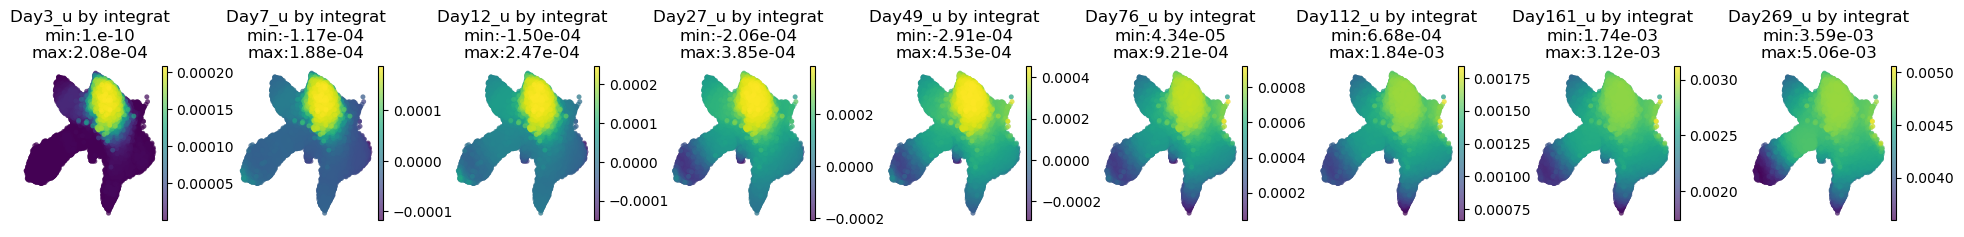

In [17]:
PINN.pl.params_in_umap(t7_ad, u_int,  timepoints=timepoints, param='u by integrat', cell_of_t=False);